#  Download the actual Dataset


In [ ]:
import requests

url = "https://isic-archive.s3.amazonaws.com/dois/10.34970-648456/milk10k.zip"
zip_path = "/content/milk10k.zip"

response = requests.get(url, stream=True)
response.raise_for_status()

total = int(response.headers.get("content-length", 0))
downloaded = 0

with open(zip_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=1024 * 1024):
        if chunk:
            f.write(chunk)
            downloaded += len(chunk)

            if total:
                print(
                    f"\rDownloaded: {downloaded / 1024**2:.1f} / "
                    f"{total / 1024**2:.1f} MB",
                    end=""
                )

print("\nDownload completed.")
print("Saved to:", zip_path)

Downloaded: 344.7 / 344.7 MB
Download completed.
Saved to: /content/milk10k.zip


# Unzip the dataset


In [ ]:
import os
import zipfile

DATASET_DIR = "/content/milk10k_dataset"

os.makedirs(DATASET_DIR, exist_ok=True)

with zipfile.ZipFile("/content/milk10k.zip", "r") as zip_ref:
    zip_ref.extractall(DATASET_DIR)

print("Extraction completed.")

Extraction completed.


#  Check the actual dataset

In [ ]:
import glob
import os

images = []

for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
    images.extend(
        glob.glob(
            os.path.join(DATASET_DIR, "**", ext),
            recursive=True
        )
    )

print("Total image files:", len(images))

Total image files: 10480


# 1. IMPORTS & HARDWARE SETUP


In [ ]:
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image, ImageFile
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Allow loading of truncated images if any exist
ImageFile.LOAD_TRUNCATED_IMAGES = True
# Device configuration (GPU on Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Compute Device: {device}")
# Seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
# Hyperparameters
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
IMAGE_SIZE = 224
DATASET_DIR = "/content/milk10k_dataset"

[*] Compute Device: cuda


# 2. LOAD METADATA & INDEX IMAGES

In [ ]:
csv_files = glob.glob(os.path.join(DATASET_DIR, "**", "*.csv"), recursive=True)
if not csv_files:
    raise FileNotFoundError(f"No metadata CSV found inside {DATASET_DIR}")
metadata_path = csv_files[0]
print(f"[*] Found metadata file: {metadata_path}")
df = pd.read_csv(metadata_path)
# 2. Identify Image ID and Diagnosis columns dynamically
id_col = next((c for c in ['isic_id', 'image_id', 'image', 'Image_id'] if c in df.columns), df.columns[0])
dx_col = next((c for c in ['diagnosis', 'dx', 'benign_malignant', 'pathology', 'label'] if c in df.columns), df.columns[1])
print(f"[*] Using Image Column: '{id_col}' | Diagnosis Column: '{dx_col}'")
# 3. Index image paths on disk
image_files = {}
for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG'):
    for p in glob.glob(os.path.join(DATASET_DIR, "**", ext), recursive=True):
        image_files[Path(p).stem] = p
df['image_path'] = df[id_col].astype(str).map(image_files)
df = df.dropna(subset=['image_path', dx_col]).reset_index(drop=True)
# 4. Map diagnoses to class indices
unique_classes = sorted(df[dx_col].astype(str).unique().tolist())
NUM_CLASSES = len(unique_classes)
CLASS_TO_IDX = {cls_name: i for i, cls_name in enumerate(unique_classes)}
IDX_TO_CLASS = {i: cls_name for i, cls_name in enumerate(unique_classes)}
df['target'] = df[dx_col].astype(str).map(CLASS_TO_IDX)
print(f"[*] Total valid indexed images: {len(df)}")
print(f"[*] Number of classes: {NUM_CLASSES}")
print(df[dx_col].value_counts())

[*] Found metadata file: /content/milk10k_dataset/metadata.csv
[*] Using Image Column: 'isic_id' | Diagnosis Column: 'attribution'
[*] Total valid indexed images: 10480
[*] Number of classes: 1
attribution
MILK study team    10480
Name: count, dtype: int64


# 3. TRAIN / VALIDATION / TEST SPLIT (70% / 15% / 15%)

In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['target'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['target'], random_state=SEED)
print(f"\n[*] Train Set : {len(train_df)} samples")
print(f"[*] Val Set   : {len(val_df)} samples")
print(f"[*] Test Set  : {len(test_df)} samples")



[*] Train Set : 7336 samples
[*] Val Set   : 1572 samples
[*] Test Set  : 1572 samples


# 4. DATASET & DATALOADER (NO AUGMENTATIONS / NO PREPROCESSING)

In [ ]:
direct_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
class Milk10kDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row['image_path']).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(row['target'], dtype=torch.long)
        return image, label
train_loader = DataLoader(Milk10kDataset(train_df, direct_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(Milk10kDataset(val_df, direct_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(Milk10kDataset(test_df, direct_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# 5. RESNET-50 MODEL SETUP (STANDARD ARCHITECTURE)

In [ ]:
model = models.resnet50(weights=ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s]


# 6. FINE-TUNING LOOP

In [ ]:
best_val_acc = 0.0
checkpoint_path = "/content/best_resnet50_milk10k.pth"
print("\n" + "="*50 + "\nSTARTING RESNET-50 FINE-TUNING\n" + "="*50)
for epoch in range(1, NUM_EPOCHS + 1):
    # --- Training ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
    train_loss_epoch = train_loss / train_total
    train_acc_epoch = train_correct / train_total
    # --- Validation ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    val_loss_epoch = val_loss / val_total
    val_acc_epoch = val_correct / val_total
    print(f"Epoch [{epoch:02d}/{NUM_EPOCHS:02d}] "
          f"| Train Loss: {train_loss_epoch:.4f} Acc: {train_acc_epoch:.4f} "
          f"| Val Loss: {val_loss_epoch:.4f} Acc: {val_acc_epoch:.4f}")
    # Save best model
    if val_acc_epoch > best_val_acc:
        best_val_acc = val_acc_epoch
        torch.save(model.state_dict(), checkpoint_path)
        print(f"  --> [Saved Best Model] Val Acc: {best_val_acc:.4f}")


STARTING RESNET-50 FINE-TUNING
Epoch [01/10] | Train Loss: 0.0000 Acc: 1.0000 | Val Loss: 0.0000 Acc: 1.0000
  --> [Saved Best Model] Val Acc: 1.0000
Epoch [02/10] | Train Loss: 0.0000 Acc: 1.0000 | Val Loss: 0.0000 Acc: 1.0000
Epoch [03/10] | Train Loss: 0.0000 Acc: 1.0000 | Val Loss: 0.0000 Acc: 1.0000
Epoch [04/10] | Train Loss: 0.0000 Acc: 1.0000 | Val Loss: 0.0000 Acc: 1.0000
Epoch [05/10] | Train Loss: 0.0000 Acc: 1.0000 | Val Loss: 0.0000 Acc: 1.0000
Epoch [06/10] | Train Loss: 0.0000 Acc: 1.0000 | Val Loss: 0.0000 Acc: 1.0000
Epoch [07/10] | Train Loss: 0.0000 Acc: 1.0000 | Val Loss: 0.0000 Acc: 1.0000
Epoch [08/10] | Train Loss: 0.0000 Acc: 1.0000 | Val Loss: 0.0000 Acc: 1.0000
Epoch [09/10] | Train Loss: 0.0000 Acc: 1.0000 | Val Loss: 0.0000 Acc: 1.0000
Epoch [10/10] | Train Loss: 0.0000 Acc: 1.0000 | Val Loss: 0.0000 Acc: 1.0000


# 7. FINAL EVALUATION ON TEST SET

In [ ]:
print("\n" + "="*50 + "\nFINAL TEST EVALUATION\n" + "="*50)
# Load best checkpoint weights
model.load_state_dict(torch.load(checkpoint_path))
model.eval()
all_labels, all_preds = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=unique_classes, zero_division=0))




FINAL TEST EVALUATION
Test Accuracy: 1.0000

Classification Report:
                 precision    recall  f1-score   support

MILK study team       1.00      1.00      1.00      1572

       accuracy                           1.00      1572
      macro avg       1.00      1.00      1.00      1572
   weighted avg       1.00      1.00      1.00      1572



# Confusion Matrix

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


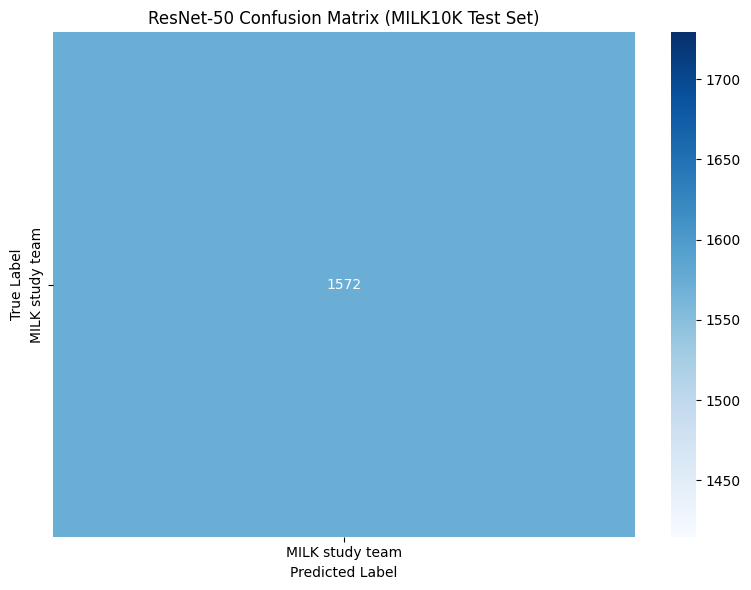

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_classes, yticklabels=unique_classes)
plt.title("ResNet-50 Confusion Matrix (MILK10K Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()